In [41]:
from sympy import *
import numpy as np

In [42]:
n, eps, r = symbols("n, epsilon, r")

In [43]:
MIR = 0.0125*n#-1/2*log(1-(n*eps)**2)
Delta = simplify(diff(MIR, n))
Sigma = simplify(diff(Delta, n)/2)
display(MIR, Delta, Sigma)

0.0125*n

0.0125000000000000

0

In [44]:
S1, G1, T, d, A, B = symbols("S', G', T, delta, A, B")

In [45]:
S_m = MIR + Sigma - Delta
S_p = MIR + Sigma + Delta
display(S_m, S_p)

0.0125*n - 0.0125

0.0125*n + 0.0125

In [46]:
S_m1 = S1 + A*(Sigma - Delta) - B/2*(Sigma - Delta)**2
S_p1 = S1 + A*(Sigma + Delta) - B/2*(Sigma + Delta)**2
lower = (S1- S_m1)/2
upper = (S_p1 - S1)/2
basin = upper + lower
display(simplify(basin), Sigma.n(n=4, subs={"n":186, "epsilon":0.005}), Delta.n(n=4, subs={"n":186, "epsilon":0.005}))
display(S_m1.n(n=4, subs={"n":186, "epsilon":0.005, A:0.95, B:0.115}), S_p1.n(n=4, subs={"n":186, "epsilon":0.005, A:0.95, B:0.115}))

0.0125*A

0

0.01250

S' - 0.01188

S' + 0.01187

In [47]:
# T1 = G1 - A*d - B/2*d**2
T1 = G1 + A*d - B/2*d**2
display(T1)

A*delta - B*delta**2/2 + G'

In [48]:
# EV = simplify((Delta - Sigma)*(G1-T1)/basin)
EV = simplify((Delta + Sigma)*(T1-G1)/basin)
EV

delta*(1.0*A - 0.5*B*delta)/A

In [49]:
display((Delta + Sigma).n(n=4, subs={"n":186, "epsilon":0.005}), (T1-G1).n(n=4, subs={d:0.03, A:0.95, B:0.115}), basin.n(n=4, subs={"n":186, "epsilon":0.005, A:0.95, B:0.115}))

0.01250

0.02845

0.01188

In [50]:
display((EV/d).evalf(n=4, subs={"n":186, "epsilon":0.005, d:0.03, A:0.95}))
tmp = simplify((EV/d).evalf(n=6, subs={"epsilon":0.005}))
tmp

1.0 - 0.01579*B

1.0 - 0.5*B*delta/A

In [51]:
tomap = lambdify((A,B,n,d), tmp)

maxd = lambdify((A,B,n), basin.n(n=6, subs={"epsilon":0.005}))

In [52]:
tomap(0.96, 0.113, 186, 0.01)
maxd(0.96, 0.113, 198)

0.012

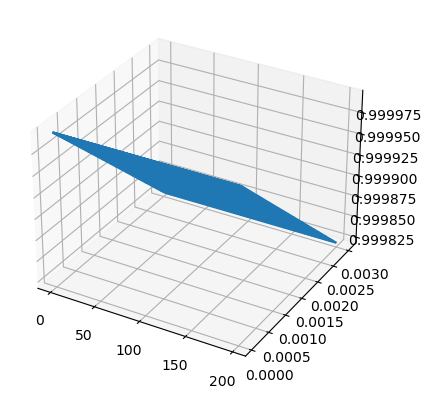

In [53]:
#%matplotlib notebook
import matplotlib.pyplot as plt

a=0.96
b=0.113
x=np.zeros((200,200))
y=np.zeros_like(x)
_y=0.00005*np.power(1.0423421498355023, np.arange(200))
z=np.full_like(x, np.nan)
for j in range(200):
    topd=maxd(a, b, j)
    for i in range(200):
        x[j,i]=j
        y[j,i]=_y[i]
        if _y[i]>topd:
            break
        z[j,i]=tomap(a, b, j, _y[i])
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_wireframe(x[:,:100],y[:,:100],z[:,:100])#, rstride = 1, cstride = 1)
#ax.plot_wireframe(x,y,np.ones_like(z), color="orange",rcount=10, ccount=10)
plt.show()

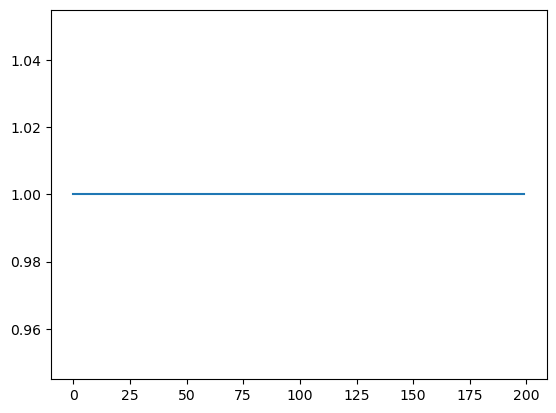

In [54]:
plt.plot(x[:,0],z[:,0])
plt.show()

In [55]:
from mpl_toolkits.mplot3d import axes3d
X, Y, Z = axes3d.get_test_data(0.05)


In [16]:
np.exp(np.log(4000)/200)

1.0423421498355023

  0%|          | 0/50000 [00:00<?, ?it/s]

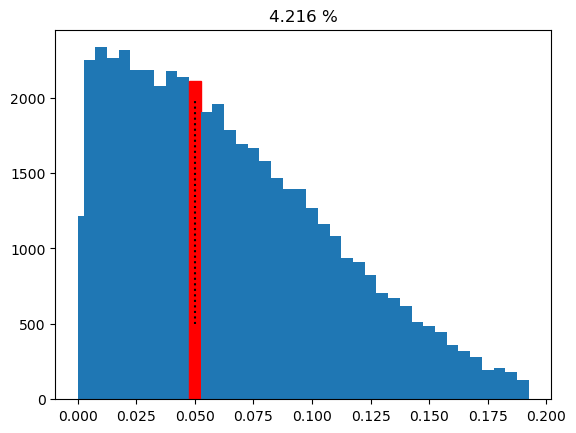

In [32]:
from scipy.stats import pearsonr
from tqdm.notebook import tqdm
increment = 0.005
i=10
means = 0, 0
correlations = [[1, i * increment], [i * increment, 1]]
n_samples = 240
n_iterations = 50000
effective = np.empty(n_iterations)
for j in tqdm(range(n_iterations)):
    points = np.random.multivariate_normal(means, correlations, n_samples).T.copy()
    effective[j] = pearsonr(*points)[0]
myBins=np.arange(0,0.2,0.005)-0.0025
myBins[0]=0
val = plt.hist(np.abs(effective), bins=myBins)
val[2][10].set_color("r")
plt.plot([0.05,0.05],[500,2000], ":k")
plt.title(f"{100*val[0][10]/n_iterations:.4} %")
plt.show()

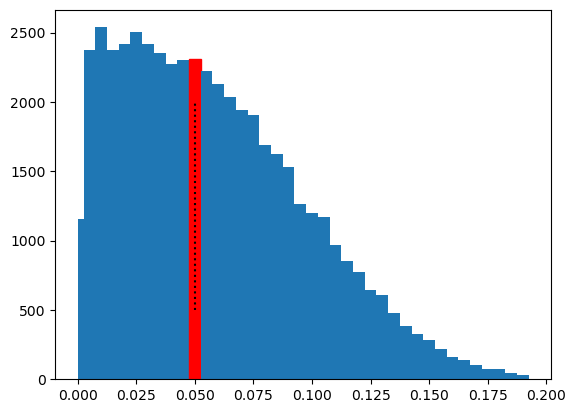

In [ ]:
myBins=np.arange(0,0.2,0.005)-0.0025
myBins[0]=0
val = plt.hist(np.abs(effective), bins=myBins)
val[2][10].set_color("r")
plt.plot([0.05,0.05],[500,2000], ":k")
plt.show()

In [197]:
myBins=np.linspace(0,1,200+1, endpoint=True)-0.005/2
myBins[0]=0

twoBins=np.linspace(0,1,200+1, endpoint=True)
twoBins[1:]-=np.diff(twoBins)/2

myBins-twoBins, np.linspace(0,1,200+1, endpoint=True)
binned = pd.cut(all_correcting["r"], myBins)
def myfunc (df):
    return pd.DataFrame([[df["MI"].mean(), df["MI"].std(), df["r"].mean(), df["r"].count(), df.name.mid]], columns=["MI", "std", "<r>", "#","r"])
results = all_correcting.groupby(binned).apply(myfunc)
display(results)

,,MI,std,<r>,#,r
r,,,,,,
"(0.0, 0.0025]",0,0.108839,0.022872,0.001243,3642,0.00125
"(0.0025, 0.0075]",0,0.108259,0.022025,0.004959,8068,0.00500
"(0.0075, 0.0125]",0,0.108533,0.022087,0.009931,7900,0.01000
"(0.0125, 0.0175]",0,0.108880,0.021772,0.014900,7633,0.01500
"(0.0175, 0.0225]",0,0.107982,0.022098,0.020009,7968,0.02000
...,...,...,...,...,...,...
"(0.972, 0.978]",0,1.187329,0.040509,0.975082,122918,0.97500
"(0.978, 0.982]",0,1.243750,0.042050,0.980110,155308,0.98000
"(0.982, 0.988]",0,1.311384,0.045609,0.985138,207082,0.98500


In [148]:
import pandas as pd
from support import single_iter
import multiprocessing as mp
from tqdm.notebook import tqdm
import numpy as np
steps=70
workers = 12
nsamples = 240
nbins = 8
iters = 50000
incre = 1 / steps
correction = np.zeros(steps)
trueval = np.zeros(steps)
pool = mp.Pool(workers)
correcting = []
for i in tqdm(range(steps), "Computing correction"):
    means = 0, 0
    corre = [[1, newrs[i]], [newrs[i], 1]]
    I = pool.map(
        single_iter,
        (
            (means, corre, nsamples, nbins)
            for __ in range(iters)
        ),
    )
    correcting.append(pd.DataFrame(np.array(I), columns=["MI","r"]))
    trueval[i] = -0.5 * np.log(1 - (newrs[i]) ** 2)

Computing correction:   0%|          | 0/70 [00:00<?, ?it/s]

In [155]:

all_correcting = pd.concat(correcting)
myBins=np.zeros(len(newrs)+1)
myBins[1:]=newrs
myBins[1:-1]+=np.diff(newrs)/2
# myBins=np.linspace(0,1,steps+1)-incre/2
# myBins[0]=0
all_correcting["r"]=all_correcting["r"].abs()
binned = pd.cut(all_correcting["r"], myBins)
def myfunc (df):
    return pd.DataFrame([[df["MI"].mean(), df["MI"].std(), df["r"].mean(), df["r"].count(), df.name.mid]], columns=["MI", "stdMI", "<r>", "#","r"])
results = all_correcting.groupby(binned).apply(myfunc)
display(results.dropna())

,,MI,std,<r>,#,r
r,,,,,,
"(0.0, 0.02015]",0,0.108622,0.022155,0.010065,31522,0.010075
"(0.02015, 0.06043]",0,0.108862,0.022734,0.040226,59379,0.040290
"(0.06043, 0.1006]",0,0.111325,0.022806,0.080347,56121,0.080515
"(0.1006, 0.1406]",0,0.114598,0.022637,0.120596,52072,0.120600
"(0.1406, 0.1804]",0,0.120336,0.022881,0.160608,49758,0.160500
...,...,...,...,...,...,...
"(0.9922, 0.9928]",0,1.450078,0.046912,0.992498,49671,0.992500
"(0.9928, 0.9934]",0,1.465181,0.047747,0.993080,49135,0.993100
"(0.9934, 0.9939]",0,1.479736,0.047948,0.993618,47602,0.993650


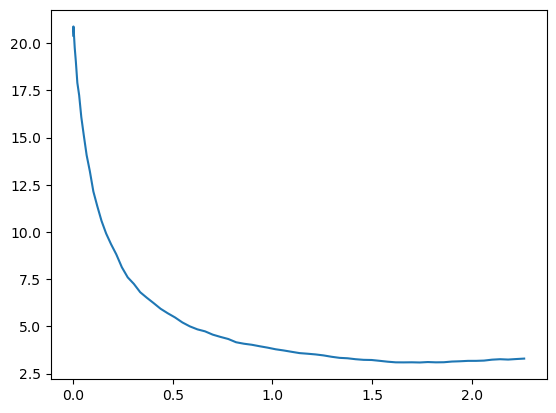

In [186]:
plt.plot(trueval,(results["std"]/results.MI).to_numpy()*100)

# plt.plot(trueval,1/trueval)

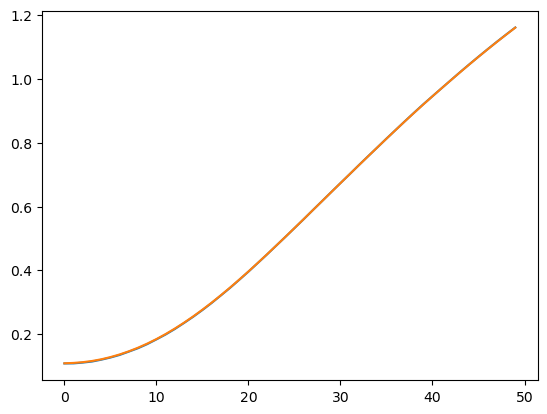

Text(0, 0.5, 'Estimated MI')

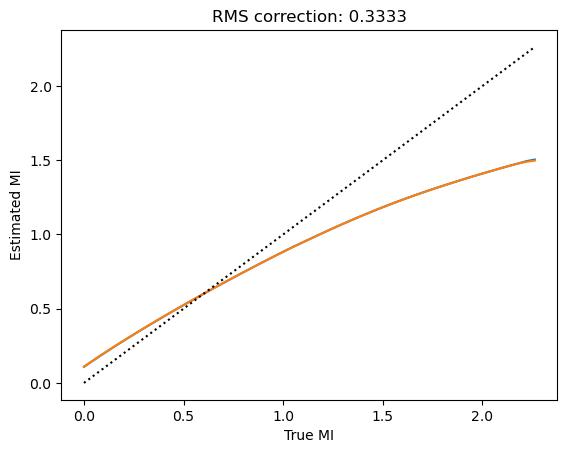

In [150]:
import matplotlib.pyplot as plt

correction = results["MI"].to_numpy()
weights = np.zeros_like(trueval)
weights[:-1] += 0.5 * (trueval[1:] - trueval[:-1])
weights[1:] += weights[:-1]
deviation = np.sqrt(
    np.average(np.square(correction[:] - trueval[:]), weights=weights)
)


tosmo = np.array(
    [
        correction[0],
    ]
    * 2
    + correction.tolist()
    + [
        correction[-1],
    ]
    * 2
)
newco = np.zeros_like(correction)
for i in range(len(correction)):
    newco[i] = np.mean(tosmo[i : i + 5])
plt.plot(correction[:50])
plt.plot(newco[:50])
plt.show()


plt.title(f"RMS correction: {deviation:.4}")
plt.plot(trueval, correction)
plt.plot(trueval, newco)
plt.plot(
    [min(trueval), max(trueval)],
    [min(trueval), max(trueval)],
    ":k",
)
plt.xlabel("True MI")
plt.ylabel("Estimated MI")

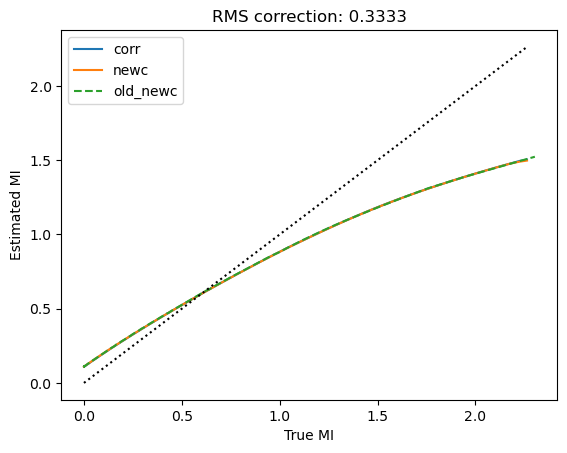

[-8.5167965   1.0848475   0.10783943]


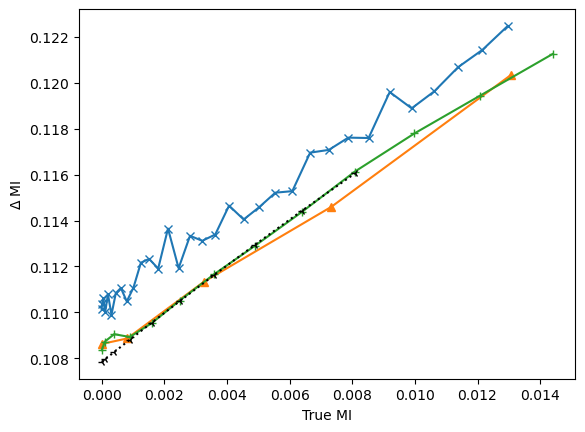

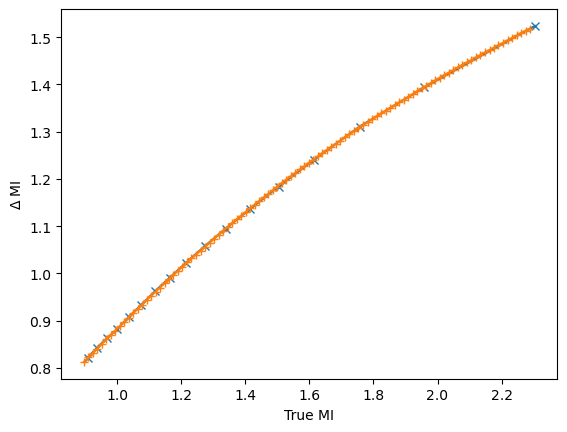

In [154]:
old_newco = np.load("/home/tani/Documents/nonLinear/MS_fMRI_bin8/newco_8.npy")
old_trueval = np.load("/home/tani/Documents/nonLinear/MS_fMRI_bin8/trueval_8.npy")


plt.title(f"RMS correction: {deviation:.4}")
plt.plot(trueval, correction, label="corr")
plt.plot(trueval, newco, label="newc")
plt.plot(old_trueval, old_newco, "--", label="old_newc")
plt.plot(
    [min(trueval), max(trueval)],
    [min(trueval), max(trueval)],
    ":k",
)
plt.legend()
plt.xlabel("True MI")
plt.ylabel("Estimated MI")
plt.show()

plt.plot(old_trueval[:33],old_newco[:33], marker="x")
plt.plot(trueval[:5],correction[:5], marker="^")
plt.plot(mid_trueval[:13],mid_correction[:13], marker="+")
v=np.polyfit(mid_trueval[4:11],mid_correction[4:11],2)
print(v)
def quadint(x, v):
    return v[0]*x**2+v[1]*x+v[2]
plt.plot(mid_trueval[:10],quadint(mid_trueval[:10],v), ":k", marker="3")
plt.xlabel("True MI")
plt.ylabel(r"$\Delta$ MI")
plt.show()
plt.plot(old_trueval[-17:],old_newco[-17:], marker="x")
plt.plot(mid_trueval[-100:],mid_correction[-100:], marker="+")
plt.xlabel("True MI")
plt.ylabel(r"$\Delta$ MI")
plt.show()

In [133]:
old_trueval[-17], trueval[-99], newrs[100]

(0.907693199929606, 0.9101732880832146, 0.9129925)

[6.25101580e-05 1.12557686e-04 1.87765221e-04 2.88455517e-04
 3.39046914e-04 3.89843956e-04 4.66494392e-04 6.48038821e-04
 7.00753106e-04 9.16377597e-04] 8
[]
[0.11013831 0.11037287 0.11061522 0.11003283 0.1107816  0.10989855] 0.11030656293097683 0.00031491801533369457
0.11045321038459512 0.11047557252655682


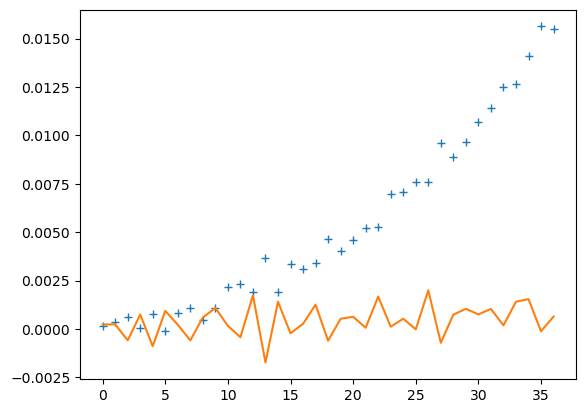

In [218]:
print(np.diff(old_trueval)[np.where(np.diff(old_newco)<0)],max(np.where(old_newco<np.mean(old_newco[:6])+np.std(old_newco[:6]))[0]))
print(np.diff(trueval)[np.where(np.diff(correction)<0)])
print(old_newco[0:6], np.mean(old_newco[:6]),  np.std(old_newco[:6]))
print(old_newco[0]+0.0003149, old_newco[8])
plt.plot(old_newco[:37]-0.11, "+")
plt.plot(np.diff(old_newco)[:37])

In [38]:
np.polyfit(trueval, correction-old_newco,1, cov=True), np.sqrt(np.diag(np.polyfit(trueval, correction-old_newco,1, cov=True)[1])), pearsonr(trueval, correction-old_newco)

((array([ 0.00094383, -0.00188997]),
  array([[ 1.57812232e-08, -4.71540566e-09],
         [-4.71540566e-09,  3.87185723e-09]])),
 array([1.25623339e-04, 6.22242495e-05]),
 PearsonRResult(statistic=0.47100486916539963, pvalue=1.9419349858033678e-12))

In [31]:
from scipy.io import loadmat
loadmat("/home/tani/Documents/nonLinear/MS_fMRI.mat")['MS_fMRI'].shape

(240, 116, 129)

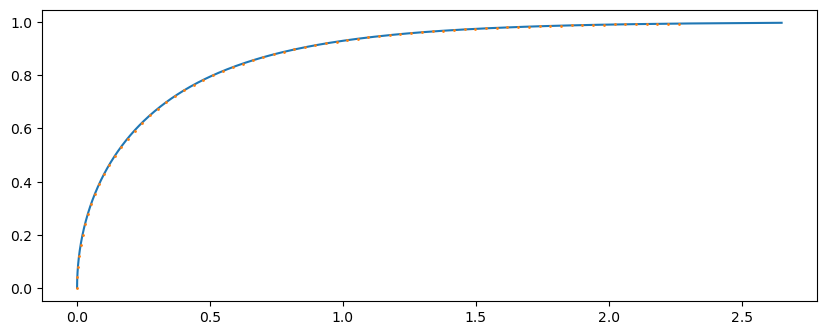

In [146]:
plt.figure(figsize=(10,4))
plt.plot(-0.5 * np.log(1 - (np.arange(400) * incre/2) ** 2),np.arange(400) * incre/2, )
plt.plot( -0.5 * np.log(1 - newrs ** 2),newrs, "o", markersize=1)
plt.gca().set_aspect("equal")

In [59]:
t = symbols("t")
m = -0.5 * log(1 - t ** 2)
dl = sqrt(diff(t,t)**2+diff(m,t)**2)
display(simplify(dl))
integrate(dl, (t,0,0.995))

sqrt(1.0*t**2/(t**2 - 1)**2 + 1)

1.0*Integral(sqrt(1.0*t**4 - 1.0*t**2 + 1.0)/Abs(t**2 - 1), (t, 0, 0.995))

In [61]:
dl_n=lambdify(t, dl)

In [144]:
eps=1e-7
length = 0
num_steps=70
interv = 2.8223199056193393/num_steps
newrs=np.zeros(num_steps)
j=1
for i in range(int(0.995*1e7)):
    length+=dl_n(i*eps)*1e-7
    if length>interv*j:
        newrs[j]=i*eps
        j+=1
print(length, j)
print(newrs)

2.8223199056193393 70
[0.        0.0403079 0.08055   0.1206592 0.1605663 0.2001986 0.239479
 0.2783253 0.3166495 0.3543575 0.3913497 0.4275213 0.4627645 0.4969702
 0.5300315 0.5618474 0.5923264 0.6213911 0.6489808 0.6750547 0.6995926
 0.7225951 0.7440821 0.7640904 0.782671  0.7998857 0.8158039 0.8304999
 0.8440502 0.8565317 0.8680197 0.8785874 0.8883046 0.8972371 0.9054472
 0.9129925 0.9199268 0.9262999 0.9321577 0.9375424 0.9424929 0.9470448
 0.9512309 0.9550812 0.9586232 0.9618821 0.964881  0.967641  0.9701817
 0.9725207 0.9746743 0.9766575 0.978484  0.9801663 0.9817161 0.9831439
 0.9844594 0.9856716 0.9867887 0.9878182 0.988767  0.9896416 0.9904478
 0.991191  0.9918762 0.9925079 0.9930902 0.9936272 0.9941224 0.9945789]


(array([0.0403079, 0.0402421, 0.0401092, 0.0399071, 0.0396323, 0.0392804,
        0.0388463, 0.0383242, 0.037708 , 0.0369922]),
 array([0.0009488, 0.0008746, 0.0008062, 0.0007432, 0.0006852, 0.0006317,
        0.0005823, 0.000537 , 0.0004952, 0.0004565]),
 array([0.00081302, 0.0024417 , 0.00407811, 0.00572702, 0.00739254,
        0.00907782, 0.01078475, 0.01251359, 0.01426252, 0.01602748]))

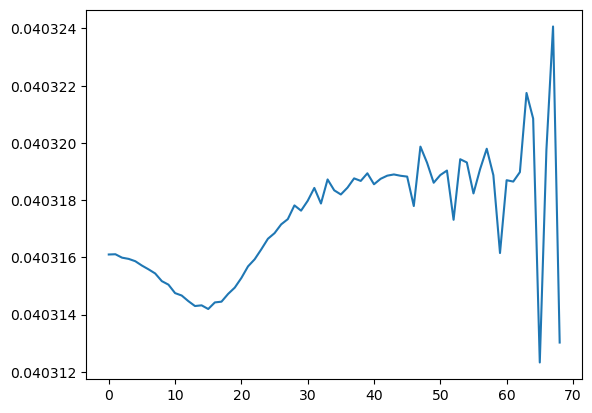

In [145]:
plt.plot(np.sqrt(np.diff( -0.5 * np.log(1 - newrs ** 2))**2+np.diff(newrs)**2))
np.diff(newrs)[:10],np.diff(newrs)[-10:], np.diff(-0.5 * np.log(1 - newrs ** 2))[:10]

In [161]:
newrs

array([0.       , 0.0403079, 0.08055  , 0.1206592, 0.1605663, 0.2001986,
       0.239479 , 0.2783253, 0.3166495, 0.3543575, 0.3913497, 0.4275213,
       0.4627645, 0.4969702, 0.5300315, 0.5618474, 0.5923264, 0.6213911,
       0.6489808, 0.6750547, 0.6995926, 0.7225951, 0.7440821, 0.7640904,
       0.782671 , 0.7998857, 0.8158039, 0.8304999, 0.8440502, 0.8565317,
       0.8680197, 0.8785874, 0.8883046, 0.8972371, 0.9054472, 0.9129925,
       0.9199268, 0.9262999, 0.9321577, 0.9375424, 0.9424929, 0.9470448,
       0.9512309, 0.9550812, 0.9586232, 0.9618821, 0.964881 , 0.967641 ,
       0.9701817, 0.9725207, 0.9746743, 0.9766575, 0.978484 , 0.9801663,
       0.9817161, 0.9831439, 0.9844594, 0.9856716, 0.9867887, 0.9878182,
       0.988767 , 0.9896416, 0.9904478, 0.991191 , 0.9918762, 0.9925079,
       0.9930902, 0.9936272, 0.9941224, 0.9945789])